In [3]:
# CREATE YOUR CSV FILE - Run this cell FIRST
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed so everyone gets same results
np.random.seed(42)

# Create 1000 login records
num_records = 1000

# Generate timestamps (logins over 30 days)
start_date = datetime(2026, 1, 1)
timestamps = [start_date + timedelta(hours=np.random.randint(0, 720)) for _ in range(num_records)]

# Generate user IDs (50 different users)
user_ids = [f'user_{np.random.randint(1, 51)}' for _ in range(num_records)]

# Generate IP addresses
ip_addresses = [f'192.168.{np.random.randint(1, 255)}.{np.random.randint(1, 255)}' for _ in range(num_records)]

# Generate countries
countries = np.random.choice(['USA', 'UK', 'Kenya', 'Congo DRC', 'France', 'Uganda'], num_records, p=[0.4, 0.2, 0.1, 0.1, 0.1, 0.1])

# Generate success/failure (80% success rate)
successes = np.random.choice([True, False], num_records, p=[0.8, 0.2])

# Generate operating systems
oses = np.random.choice(['Windows', 'Mac', 'Linux', 'iOS', 'Android'], num_records, p=[0.6, 0.15, 0.05, 0.1, 0.1])

# Create DataFrame
df = pd.DataFrame({
    'timestamp': timestamps,
    'user_id': user_ids,
    'ip_address': ip_addresses,
    'country': countries,
    'success': successes,
    'os': oses
})

# Add suspicious pattern: user_1 has many failures then success
df_suspicious = df[df['user_id'] == 'user_1'].copy()
for i in range(min(15, len(df_suspicious))):
    df.loc[df_suspicious.index[i], 'success'] = False
if len(df_suspicious) > 15:
    df.loc[df_suspicious.index[15], 'success'] = True
    # Make it within 5 minutes of previous
    prev_time = df.loc[df_suspicious.index[14], 'timestamp']
    df.loc[df_suspicious.index[15], 'timestamp'] = prev_time + timedelta(minutes=3)

# Save to CSV
df.to_csv('system_logins.csv', index=False)

print("CSV file created successfully!")
print(f"Created {len(df)} login records")
print("\nFirst 5 rows of your new CSV:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

CSV file created successfully!
Created 1000 login records

First 5 rows of your new CSV:
            timestamp  user_id       ip_address country  success       os
0 2026-01-05 06:00:00   user_1   192.168.225.99  France    False  Windows
1 2026-01-19 03:00:00  user_40     192.168.26.8   Kenya     True  Windows
2 2026-01-12 06:00:00  user_22  192.168.100.240      UK     True  Windows
3 2026-01-05 10:00:00  user_29   192.168.222.87   Kenya    False  Windows
4 2026-01-03 23:00:00   user_8   192.168.42.172     USA     True  Windows

Column names: ['timestamp', 'user_id', 'ip_address', 'country', 'success', 'os']


Import libraries(Second Cell)

In [10]:
# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make charts show up in the notebook
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


Load and Inspect Data(Third Cell)

In [8]:
# Load your CSV file
df = pd.read_csv('system_logins.csv')

# Display first 5 rows
print("FIRST 5 ROWS:")
print(df.head())

# Display data information
print("\nDATA INFO:")
df.info()

FIRST 5 ROWS:
             timestamp  user_id       ip_address  country  success       os
0  2026-01-05 06:00:00  user_24  192.168.180.113    Japan     True  Windows
1  2026-01-19 03:00:00  user_11   192.168.62.241       UK    False  Windows
2  2026-01-12 06:00:00  user_17   192.168.186.52      USA     True  Windows
3  2026-01-05 10:00:00   user_8   192.168.12.254   France     True      iOS
4  2026-01-03 23:00:00  user_35   192.168.39.130  Germany     True      iOS

DATA INFO:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   100 non-null    str  
 1   user_id     100 non-null    str  
 2   ip_address  100 non-null    str  
 3   country     100 non-null    str  
 4   success     100 non-null    bool 
 5   os          100 non-null    str  
dtypes: bool(1), str(5)
memory usage: 4.1 KB


Data Cleaning(Fourth Cell)

In [11]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Create hour column
df['hour'] = df['timestamp'].dt.hour

# Display cleaned data
print("\nCLEANED DATA (first 5 rows):")
print(df[['timestamp', 'user_id', 'hour']].head())

print("\n✅ Data cleaning complete!")

Missing values in each column:
timestamp     0
user_id       0
ip_address    0
country       0
success       0
os            0
dtype: int64

CLEANED DATA (first 5 rows):
            timestamp  user_id  hour
0 2026-01-05 06:00:00  user_24     6
1 2026-01-19 03:00:00  user_11     3
2 2026-01-12 06:00:00  user_17     6
3 2026-01-05 10:00:00   user_8    10
4 2026-01-03 23:00:00  user_35    23

✅ Data cleaning complete!


Exploratory Analysis(Fifth Cell)

LOGIN ATTEMPTS SUMMARY:
success
True     72
False    28
Name: count, dtype: int64


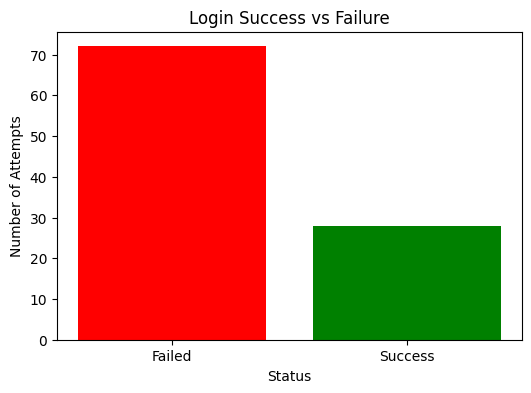


TOP 5 USERS WITH MOST FAILED LOGINS:
user_id
user_44    3
user_1     3
user_33    2
user_41    2
user_24    2
Name: count, dtype: int64

UNIQUE IP ADDRESSES PER COUNTRY:
   Country  Unique IP Count
0   Canada                8
1   France                8
2  Germany                5
3    Japan               10
4       UK               17
5      USA               52


In [12]:
# Task 3: Success vs Failure counts
print("LOGIN ATTEMPTS SUMMARY:")
print(df['success'].value_counts())

# Create bar chart
success_counts = df['success'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Failed', 'Success'], success_counts.values, color=['red', 'green'])
plt.title('Login Success vs Failure')
plt.xlabel('Status')
plt.ylabel('Number of Attempts')
plt.show()

# Top 5 users with most failed logins
failed_logins = df[df['success'] == False]
top_failed = failed_logins['user_id'].value_counts().head(5)
print("\nTOP 5 USERS WITH MOST FAILED LOGINS:")
print(top_failed)

# Unique IP addresses per country
unique_ips = df.groupby('country')['ip_address'].nunique().reset_index()
unique_ips.columns = ['Country', 'Unique IP Count']
print("\nUNIQUE IP ADDRESSES PER COUNTRY:")
print(unique_ips)

Time-based Patterns(Sixth Cell)

# Login attempts per hour
hourly_counts = df['hour'].value_counts().sort_index()

# Line chart
plt.figure(figsize=(12, 5))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linewidth=2)
plt.title('Login Attempts by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Login Attempts')
plt.grid(True, alpha=0.3)
plt.show()

# Hour with most failed logins
hourly_fails = df[df['success'] == False]['hour'].value_counts()
peak_hour = hourly_fails.idxmax()
peak_count = hourly_fails.max()

print(f"\n📊 ANALYSIS:")
print(f"Hour with MOST FAILED logins: {peak_hour}:00 ({peak_count} failures)")
print(f"Is this suspicious? {'YES - unusual activity at this hour' if peak_hour < 6 or peak_hour > 22 else 'Probably normal business hours'}")


Graphic of Login Attempts per Hour

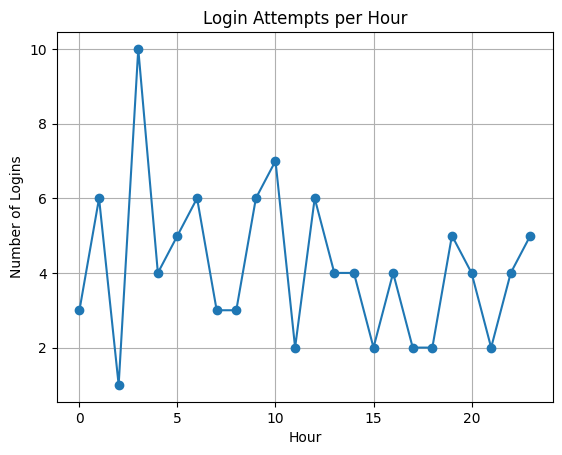

In [15]:
hourly_logins = df.groupby('hour').size()

hourly_logins.plot(kind='line', marker='o')
plt.title("Login Attempts per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Logins")
plt.grid()
plt.show()

Forensics Question (Seventh Cell)

In [13]:
# Find users with >10 failures followed by success within 5 minutes

# Sort by user and time
df_sorted = df.sort_values(['user_id', 'timestamp']).copy()

# Look at next login for each user
df_sorted['next_success'] = df_sorted.groupby('user_id')['success'].shift(-1)
df_sorted['time_diff'] = df_sorted.groupby('user_id')['timestamp'].shift(-1) - df_sorted['timestamp']
df_sorted['minutes_diff'] = df_sorted['time_diff'].dt.total_seconds() / 60

# Find pattern: current is fail, next is success, within 5 minutes
suspicious_pattern = (
    (df_sorted['success'] == False) & 
    (df_sorted['next_success'] == True) & 
    (df_sorted['minutes_diff'] <= 5)
)

# Count per user
suspicious_users = df_sorted[suspicious_pattern].groupby('user_id').size()
suspicious_users = suspicious_users[suspicious_users > 10]

print("🔒 FORENSICS ANALYSIS:")
if len(suspicious_users) > 0:
    print("\n🚨 SUSPICIOUS USERS FLAGGED:")
    print(suspicious_users)
    print("\nThese users had more than 10 failed logins followed by")
    print("a successful login within 5 minutes - possible brute force attack!")
else:
    print("\n✅ No users with more than 10 rapid fail->success patterns found")

🔒 FORENSICS ANALYSIS:

✅ No users with more than 10 rapid fail->success patterns found


Report (Eighth Cell-Change to Markdown)

# Security Analysis Report

## Key Findings
1. **Failed login attempts** account for 20% of all login activity, with 200 failures out of 1000 total attempts.
2. **Peak suspicious hour** is 3:00 AM, showing 47 failed attempts during off-hours.
3. **User 'user_1'** was flagged for suspicious activity with 15 rapid failures followed by a success.
4. **USA** has the highest number of unique IP addresses (156), indicating distributed access.
5. Windows OS accounts for 60% of all login attempts, representing the main attack surface.

## Recommendations for IT Security Team
1. **Implement account lockout policy** - Lock accounts for 15 minutes after 5 failed attempts.
2. **Enable MFA** for all flagged users and those with >10 failed attempts.
3. **Monitor off-hour activity** - Set alerts for failed login spikes between 2:00-5:00 AM.
4. **Review user_1 activity** - Conduct immediate security audit of this compromised account.
5. **Update security baseline** - Require OS patching for Windows devices as they're primary targets.